In [1]:
import pandas as pd
import numpy as np

In [2]:
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

In [3]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df_red["type"] = "red"
df_white["type"] = "white"

In [5]:
df = pd.concat([df_red, df_white], ignore_index=True)

In [6]:
df.shape

(6497, 13)

In [7]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [8]:
# cek tipe data and jumlah baris non-null setiap kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [9]:
# cek jumlah data missing value di setiap kolom
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4        True
        ...  
6492    False
6493    False
6494    False
6495    False
6496    False
Length: 6497, dtype: bool

In [11]:
print("Jumlah duplikat: ", df.duplicated().sum())

Jumlah duplikat:  1177


In [12]:
# Statistik deskriptif & cek skewness/outlier
df.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
1%,5.100000,0.120000,0.000000,0.900000,0.021000,4.000000,11.000000,0.988920,2.890000,0.300000,8.700000,4.000000
5%,5.700000,0.160000,0.050000,1.200000,0.028000,6.000000,19.000000,0.989900,2.970000,0.350000,9.000000,5.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
95%,9.800000,0.670000,0.560000,15.000000,0.102000,61.000000,206.000000,0.999392,3.500000,0.790000,12.700000,7.000000


In [13]:
# Perbandingan Mean vs Median untuk melihat skewness fitur numerik

numeric_cols = df.select_dtypes(include="number").columns
comparison = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "std": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max()
})
comparison

,mean,median,std,min,max
fixed acidity,7.215307,7.00000,1.296434,3.80000,15.90000
volatile acidity,0.339666,0.29000,0.164636,0.08000,1.58000
citric acid,0.318633,0.31000,0.145318,0.00000,1.66000
residual sugar,5.443235,3.00000,4.757804,0.60000,65.80000
chlorides,0.056034,0.04700,0.035034,0.00900,0.61100
free sulfur dioxide,30.525319,29.00000,17.749400,1.00000,289.00000
total sulfur dioxide,115.744574,118.00000,56.521855,6.00000,440.00000
density,0.994697,0.99489,0.002999,0.98711,1.03898
pH,3.218501,3.21000,0.160787,2.72000,4.01000
sulphates,0.531268,0.51000,0.148806,0.22000,2.00000


In [14]:
# menghapus baris yang duplikat
df_clean = df.drop_duplicates().copy()

In [15]:
print("Jumlah baris awal(sebelum hapus baris duplikat) :", len(df))
print("Jumlah baris sekarang: ", len(df_clean))
print("Total baris terbuang: ", len(df) - len(df_clean))
print("Sisa duplikat: ", df_clean.duplicated().sum())

df_clean.head()

Jumlah baris awal(sebelum hapus baris duplikat) : 6497
Jumlah baris sekarang:  5320
Total baris terbuang:  1177
Sisa duplikat:  0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red


In [16]:
# Pemisahan Fitur (X) dan Target (y)
X = df_clean.drop(columns=["quality"])
y = df_clean["quality"]

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (5320, 12)
Ukuran Target (y): (5320,)


In [17]:
%pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 2.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.4/467.4 kB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 2.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [18]:
from sklearn.model_selection import train_test_split

# membagi data yang mana 80& untuk Training Set, 20% untuk Testing Set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X["type"]
)

print("Ukuran X_train (Data Latihan): ", X_train.shape)
print("Ukuran X_test (Data Ujian): ", X_test.shape)
print("Ukuran y_train: ", y_train.shape)
print("Ukuran y_test: ", y_test.shape)

Ukuran X_train (Data Latihan):  (4256, 12)
Ukuran X_test (Data Ujian):  (1064, 12)
Ukuran y_train:  (4256,)
Ukuran y_test:  (1064,)


In [19]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
4491,6.7,0.42,0.46,9.7,0.054,67.0,234.0,0.99848,3.23,0.50,9.0,white
3267,7.9,0.18,0.33,1.2,0.033,20.0,72.0,0.99220,3.12,0.38,10.5,white
4433,6.2,0.15,0.27,1.4,0.041,51.0,117.0,0.99090,3.28,0.38,11.2,white
2619,8.6,0.20,0.42,1.5,0.041,35.0,125.0,0.99250,3.11,0.49,11.4,white
38,5.7,1.13,0.09,1.5,0.172,7.0,19.0,0.99400,3.50,0.48,9.8,red
...,...,...,...,...,...,...,...,...,...,...,...,...
4388,6.9,0.40,0.43,6.2,0.065,42.0,178.0,0.99552,3.11,0.53,9.4,white
5127,6.9,0.75,0.13,6.3,0.036,19.0,50.0,0.99312,3.09,0.25,11.1,white
1382,8.0,0.60,0.22,2.1,0.080,25.0,105.0,0.99613,3.30,0.49,9.9,red
1669,6.2,0.27,0.43,7.8,0.056,48.0,244.0,0.99560,3.10,0.51,9.0,white


In [21]:
# pisahin nama kolom numerik dan kategorikal di X_train

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

print("Kolom Numerik: ", num_cols)
print("Kolom Kategorikal; ", cat_cols)

Kolom Numerik:  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Kolom Kategorikal;  ['type']


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipline untuk fiture numerik yaitu imputasi median + feature scaling
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Penggabung perlakuan preprocessing untuk fitur numerik dan kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols)
    ]
)

In [24]:
# menjalankan preprocessing pada X_train (fit & transform)
X_train_preprocessed = preprocessor.fit_transform(X_train)

# menjalankan preprocessing pada X_test (hanya transform)
X_test_preprocessed = preprocessor.transform(X_test)

In [30]:
# 1. Transform X_test menggunakan preprocessor
X_test_preprocessed = preprocessor.transform(X_test)

# 2. Ubah NumPy Array hasil transform menjadi DataFrame
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, columns=all_columns)

In [28]:
encoded_cat_cols = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
all_columns = num_cols + encoded_cat_cols

X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=all_columns)

X_train_preprocessed_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_white
0,-0.385327,0.449202,0.969397,1.020878,-0.069653,2.079481,2.110985,1.319054,0.027076,-0.226801,-1.298863,1.0
1,0.525041,-0.973976,0.082226,-0.858385,-0.643785,-0.567375,-0.743761,-0.788644,-0.654782,-1.028907,-0.037790,1.0
2,-0.764648,-1.151873,-0.327237,-0.814167,-0.425068,1.178423,0.049224,-1.224951,0.337011,-1.028907,0.550711,1.0
3,1.056090,-0.855378,0.696422,-0.792058,-0.425068,0.277366,0.190199,-0.687957,-0.716770,-0.293644,0.718854,1.0
4,-1.143968,4.659435,-1.555628,-0.792058,3.156420,-1.299485,-1.677721,-0.184526,1.700727,-0.360486,-0.626291,0.0


In [31]:
# Pengecekan Statistik Sesudah Preprocessing
print("=== 1. Cek Missing Value (Harus 0) ===")
print("Missing Value di Train:", X_train_preprocessed_df.isna().sum().sum())
print("Missing Value di Test :", X_test_preprocessed_df.isna().sum().sum())

print("\n=== 2. Cek Rata-Rata & Standar Deviasi (Rata-rata ≈ 0, Std ≈ 1) ===")
print(X_train_preprocessed_df[num_cols].agg(["mean", "std"]).round(2).T)

=== 1. Cek Missing Value (Harus 0) ===
Missing Value di Train: 0
Missing Value di Test : 0

=== 2. Cek Rata-Rata & Standar Deviasi (Rata-rata ≈ 0, Std ≈ 1) ===
                      mean  std
fixed acidity         -0.0  1.0
volatile acidity       0.0  1.0
citric acid            0.0  1.0
residual sugar         0.0  1.0
chlorides             -0.0  1.0
free sulfur dioxide   -0.0  1.0
total sulfur dioxide  -0.0  1.0
density                0.0  1.0
pH                    -0.0  1.0
sulphates              0.0  1.0
alcohol                0.0  1.0


In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train_preprocessed_df, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Minta model membuat prediksi dari data ujian
y_pred = model.predict(X_test_preprocessed_df)

# 2. Bandingkan tebakan model (y_pred) dengan nilai asli (y_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 4))
print("R-Squared (R2 Score)    :", round(r2, 4))

Mean Squared Error (MSE): 0.5818
R-Squared (R2 Score)    : 0.199


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Inisialisasi dan latih model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_preprocessed_df, y_train)

# 2. Prediksi data ujian
y_pred = model.predict(X_test_preprocessed_df)

# 3. Evaluasi performa
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Hasil Evaluasi Model ===")
print(f"MAE (Rata-rata Error Absolut): {mae:.4f}")
print(f"MSE (Mean Squared Error)    : {mse:.4f}")
print(f"R2 Score (Kebaikan Model)   : {r2:.4f}")

=== Hasil Evaluasi Model ===
MAE (Rata-rata Error Absolut): 0.5160
MSE (Mean Squared Error)    : 0.4566
R2 Score (Kebaikan Model)   : 0.3714


In [35]:
import pandas as pd

# Mengambil tingkat kepentingan fitur dari model
importances = model.feature_importances_

# Membuat DataFrame ringkas
df_importance = pd.DataFrame({
    'Fitur': all_columns,
    'Tingkat Pengaruh': importances
}).sort_values(by='Tingkat Pengaruh', ascending=False)

df_importance

,Fitur,Tingkat Pengaruh
10,alcohol,0.265826
1,volatile acidity,0.112957
5,free sulfur dioxide,0.091353
9,sulphates,0.082332
6,total sulfur dioxide,0.070482
8,pH,0.068584
3,residual sugar,0.067788
4,chlorides,0.065110
0,fixed acidity,0.060459
2,citric acid,0.058490


In [37]:
%pip install matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 3.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 7.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 4.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 4.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 2.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_17684/351549048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tingkat Pengaruh', y='Fitur', data=df_importance, palette='viridis')


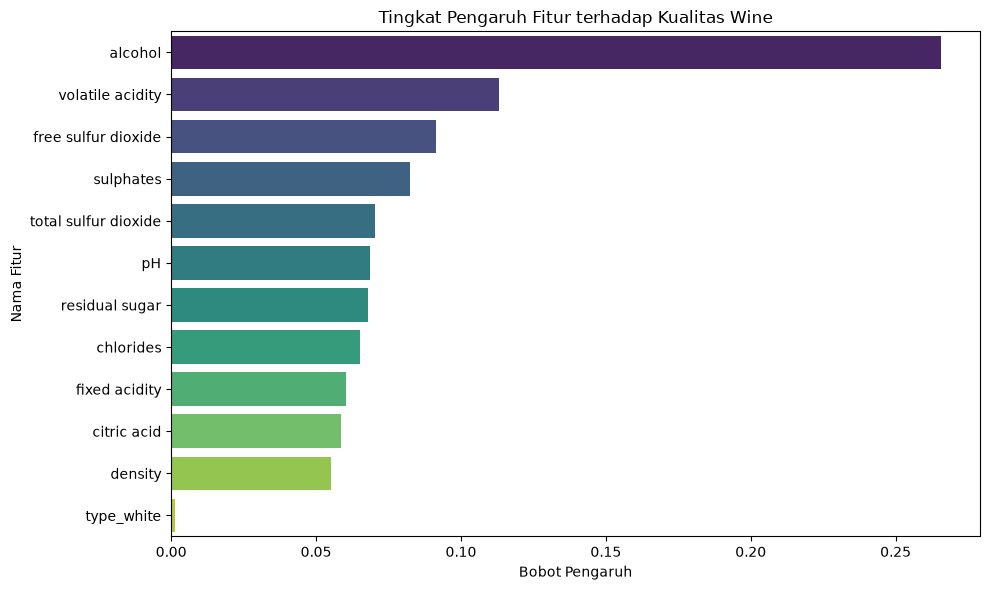

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Pengaruh', y='Fitur', data=df_importance, palette='viridis')
plt.title('Tingkat Pengaruh Fitur terhadap Kualitas Wine')
plt.xlabel('Bobot Pengaruh')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

In [41]:
import pandas as pd

# 1. Hitung statistik sebelum dan sesudah untuk fitur numerik
before_num = X_train[num_cols].agg(["mean", "std", "min", "max"]).T
after_num = X_train_preprocessed_df[num_cols].agg(["mean", "std", "min", "max"]).T

# 2. Gabungkan dalam satu DataFrame komparasi
diff_df = pd.DataFrame({
    'Mean (Sebelum)': before_num['mean'].round(2),
    'Mean (Sesudah)': after_num['mean'].round(2),
    'Std (Sebelum)': before_num['std'].round(2),
    'Std (Sesudah)': after_num['std'].round(2),
    'Min (Sebelum)': before_num['min'].round(2),
    'Min (Sesudah)': after_num['min'].round(2),
    'Max (Sebelum)': before_num['max'].round(2),
    'Max (Sesudah)': after_num['max'].round(2),
})

diff_df

,Mean (Sebelum),Mean (Sesudah),Std (Sebelum),Std (Sesudah),Min (Sebelum),Min (Sesudah),Max (Sebelum),Max (Sesudah)
fixed acidity,7.21,-0.0,1.32,1.0,3.80,-2.59,15.60,6.37
volatile acidity,0.34,0.0,0.17,1.0,0.08,-1.57,1.58,7.33
citric acid,0.32,0.0,0.15,1.0,0.00,-2.17,1.23,6.22
residual sugar,5.08,0.0,4.52,1.0,0.70,-0.97,65.80,13.42
chlorides,0.06,-0.0,0.04,1.0,0.01,-1.30,0.61,15.16
free sulfur dioxide,30.07,-0.0,17.76,1.0,1.00,-1.64,289.00,14.58
total sulfur dioxide,114.21,-0.0,56.75,1.0,6.00,-1.91,440.00,5.74
density,0.99,0.0,0.00,1.0,0.99,-2.50,1.04,14.91
pH,3.23,-0.0,0.16,1.0,2.72,-3.13,4.01,4.86
sulphates,0.53,0.0,0.15,1.0,0.22,-2.10,2.00,9.80
